In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
loan_data = pd.read_csv("loan_approval_data.csv")

In [3]:
loan_data.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [4]:
loan_data.shape

(1000, 20)

In [5]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

 # Handling Missing Values

In [6]:
loan_data.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [7]:
loan_data.dtypes

Applicant_ID          float64
Applicant_Income      float64
Coapplicant_Income    float64
Employment_Status      object
Age                   float64
Marital_Status         object
Dependents            float64
Credit_Score          float64
Existing_Loans        float64
DTI_Ratio             float64
Savings               float64
Collateral_Value      float64
Loan_Amount           float64
Loan_Term             float64
Loan_Purpose           object
Property_Area          object
Education_Level        object
Gender                 object
Employer_Category      object
Loan_Approved          object
dtype: object

In [8]:
# MY code
# for col in loan_data.columns:
#     if loan_data[col].dtypes == "float64":
#         loan_data[col] = loan_data[col].fillna(loan_data[col].mean())
#     else:
#         loan_data[col] = loan_data[col].fillna(loan_data[col].mode()[0])

In [9]:
#learnt Code
categorical_data = loan_data.select_dtypes(include = ["object"]).columns
numerical_data = loan_data.select_dtypes(include = ["number"]).columns

In [10]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy = "mean")
loan_data[numerical_data] = num_imp.fit_transform(loan_data[numerical_data])

cat_imp = SimpleImputer(strategy = "most_frequent")
loan_data[categorical_data] = cat_imp.fit_transform(loan_data[categorical_data])


In [11]:
loan_data.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA

Text(0.5, 1.0, 'Loan Approval')

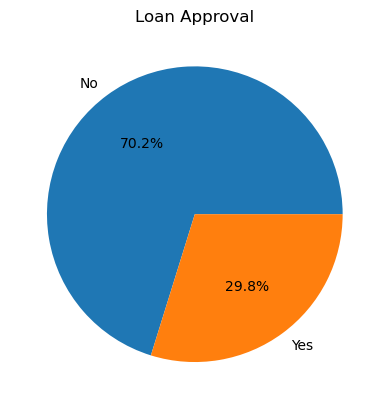

In [12]:
 # how balanced our data is 
cls_count = loan_data["Loan_Approved"].value_counts()
plt.pie(cls_count,labels = ["No","Yes"], autopct = "%1.1f%%")
plt.title("Loan Approval")

[Text(0, 0, '621'), Text(0, 0, '379')]

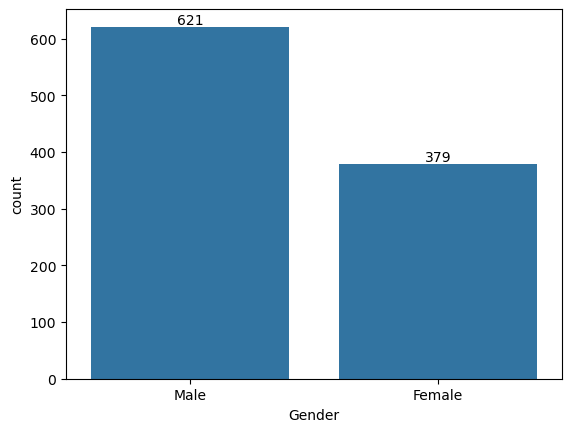

In [13]:
gender_count = loan_data["Gender"].value_counts()
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

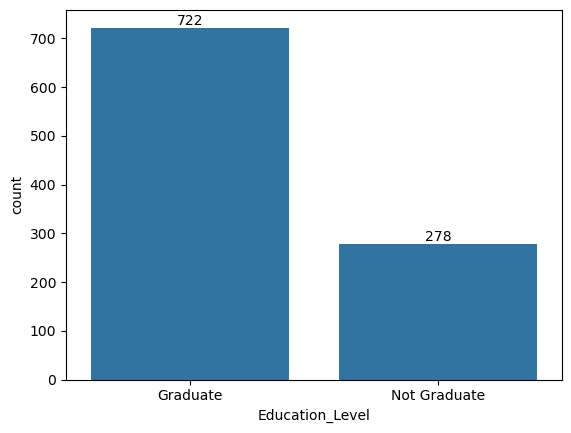

In [14]:
edu_count = loan_data["Education_Level"].value_counts()
ax = sns.barplot(edu_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

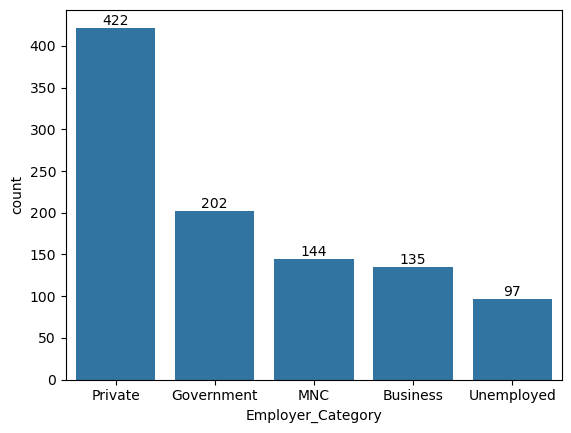

In [15]:
cat_count = loan_data["Employer_Category"].value_counts()
ax = sns.barplot(cat_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

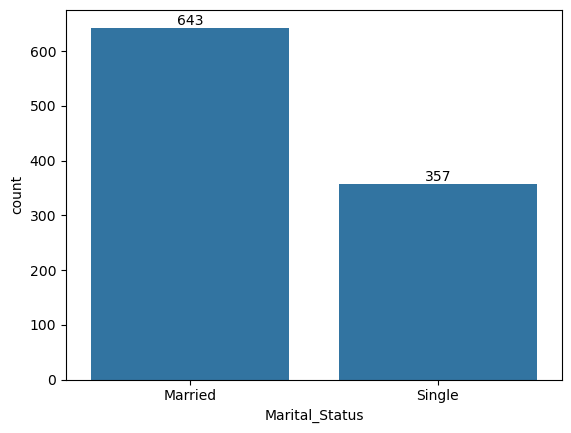

In [16]:
mar_count = loan_data["Marital_Status"].value_counts()
ax = sns.barplot(mar_count)
ax.bar_label(ax.containers[0])

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

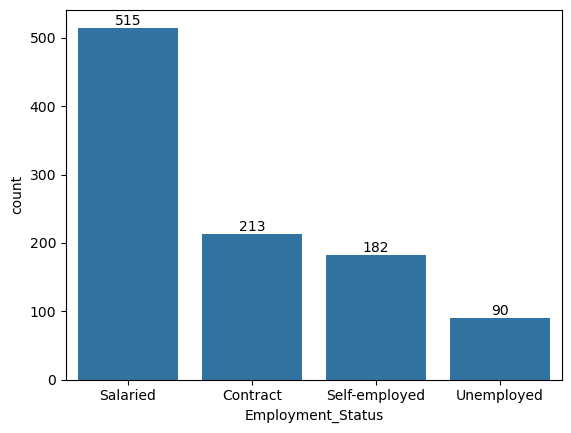

In [17]:
status_count = loan_data["Employment_Status"].value_counts()
ax = sns.barplot(status_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

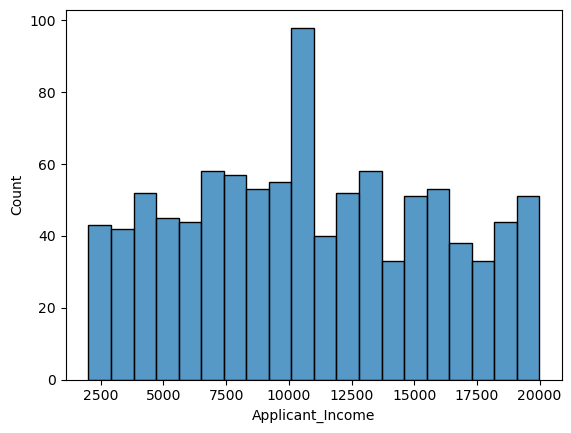

In [18]:
sns.histplot(
    data = loan_data,
    x = "Applicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

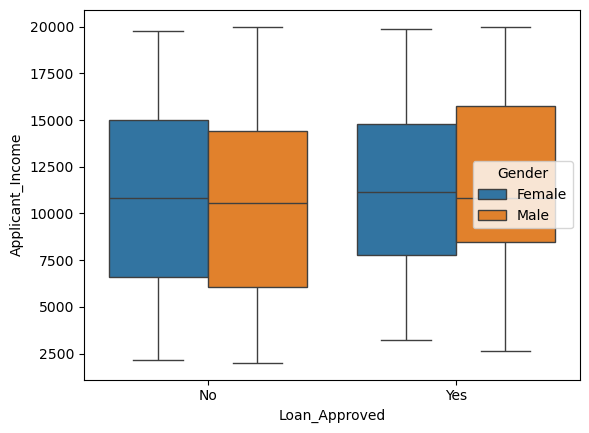

In [19]:
sns.boxplot(
    data = loan_data,
    x = "Loan_Approved",
    y = "Applicant_Income",
    hue = "Gender"
)

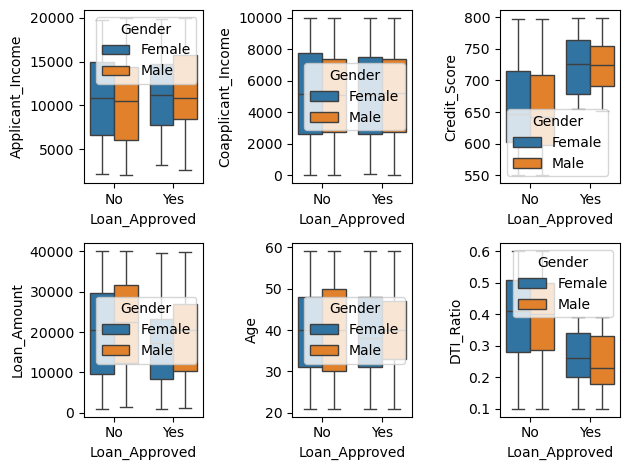

In [20]:
fig,axes = plt.subplots(2,3)
sns.boxplot(ax = axes[0,0],data = loan_data,x = "Loan_Approved",y = "Applicant_Income",hue = "Gender")
sns.boxplot(ax = axes[0,1],data = loan_data,x = "Loan_Approved",y = "Coapplicant_Income",hue = "Gender")
sns.boxplot(ax = axes[0,2],data = loan_data,x = "Loan_Approved",y = "Credit_Score",hue = "Gender")
sns.boxplot(ax = axes[1,0],data = loan_data,x = "Loan_Approved",y = "Loan_Amount",hue = "Gender")
sns.boxplot(ax = axes[1,1],data = loan_data,x = "Loan_Approved",y = "Age",hue = "Gender")
sns.boxplot(ax = axes[1,2],data = loan_data,x = "Loan_Approved",y = "DTI_Ratio",hue = "Gender")

plt.tight_layout()

In [21]:
loan_data = loan_data.drop("Applicant_ID",axis = 1)

In [22]:
loan_data

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


# Feature Encoding

In [23]:
# LabelEncoding and OneHotEncoding
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le = LabelEncoder()
loan_data["Loan_Approved"] = le.fit_transform(loan_data["Loan_Approved"])

In [24]:
loan_data["Education_Level"] = le.fit_transform(loan_data["Education_Level"])

In [25]:
loan_data

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,1,Male,Unemployed,0
996,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,0,Female,Government,0
997,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,0,Male,MNC,0
998,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,0,Male,Private,1


In [26]:
onc = OneHotEncoder(drop = "first",sparse_output = False,handle_unknown = "ignore")
cols = ["Employer_Category","Gender","Property_Area","Loan_Purpose","Marital_Status","Employment_Status"]
encoded_data = onc.fit_transform(loan_data[cols])

In [27]:
encoded_data_frame = pd.DataFrame(encoded_data, columns = onc.get_feature_names_out(cols), index = loan_data.index)

In [28]:
loan_data = pd.concat([loan_data.drop(columns = cols),encoded_data_frame],axis = 1)

In [29]:
loan_data

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Property_Area_Semiurban,Property_Area_Urban,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,17795.000000,1387.0,51.0,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2860.000000,2679.0,46.0,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,7390.000000,2106.0,25.0,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,13964.000000,8173.0,40.0,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,13284.000000,4223.0,31.0,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,10852.571579,9092.0,58.0,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
996,3279.000000,6356.0,58.0,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
997,15192.000000,8433.0,48.0,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
998,9083.000000,7380.0,50.0,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0


In [30]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

# Corelation

In [33]:
num_cols = loan_data.select_dtypes(include = "number")
coor_matrix = num_cols.corr()

In [35]:
num_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

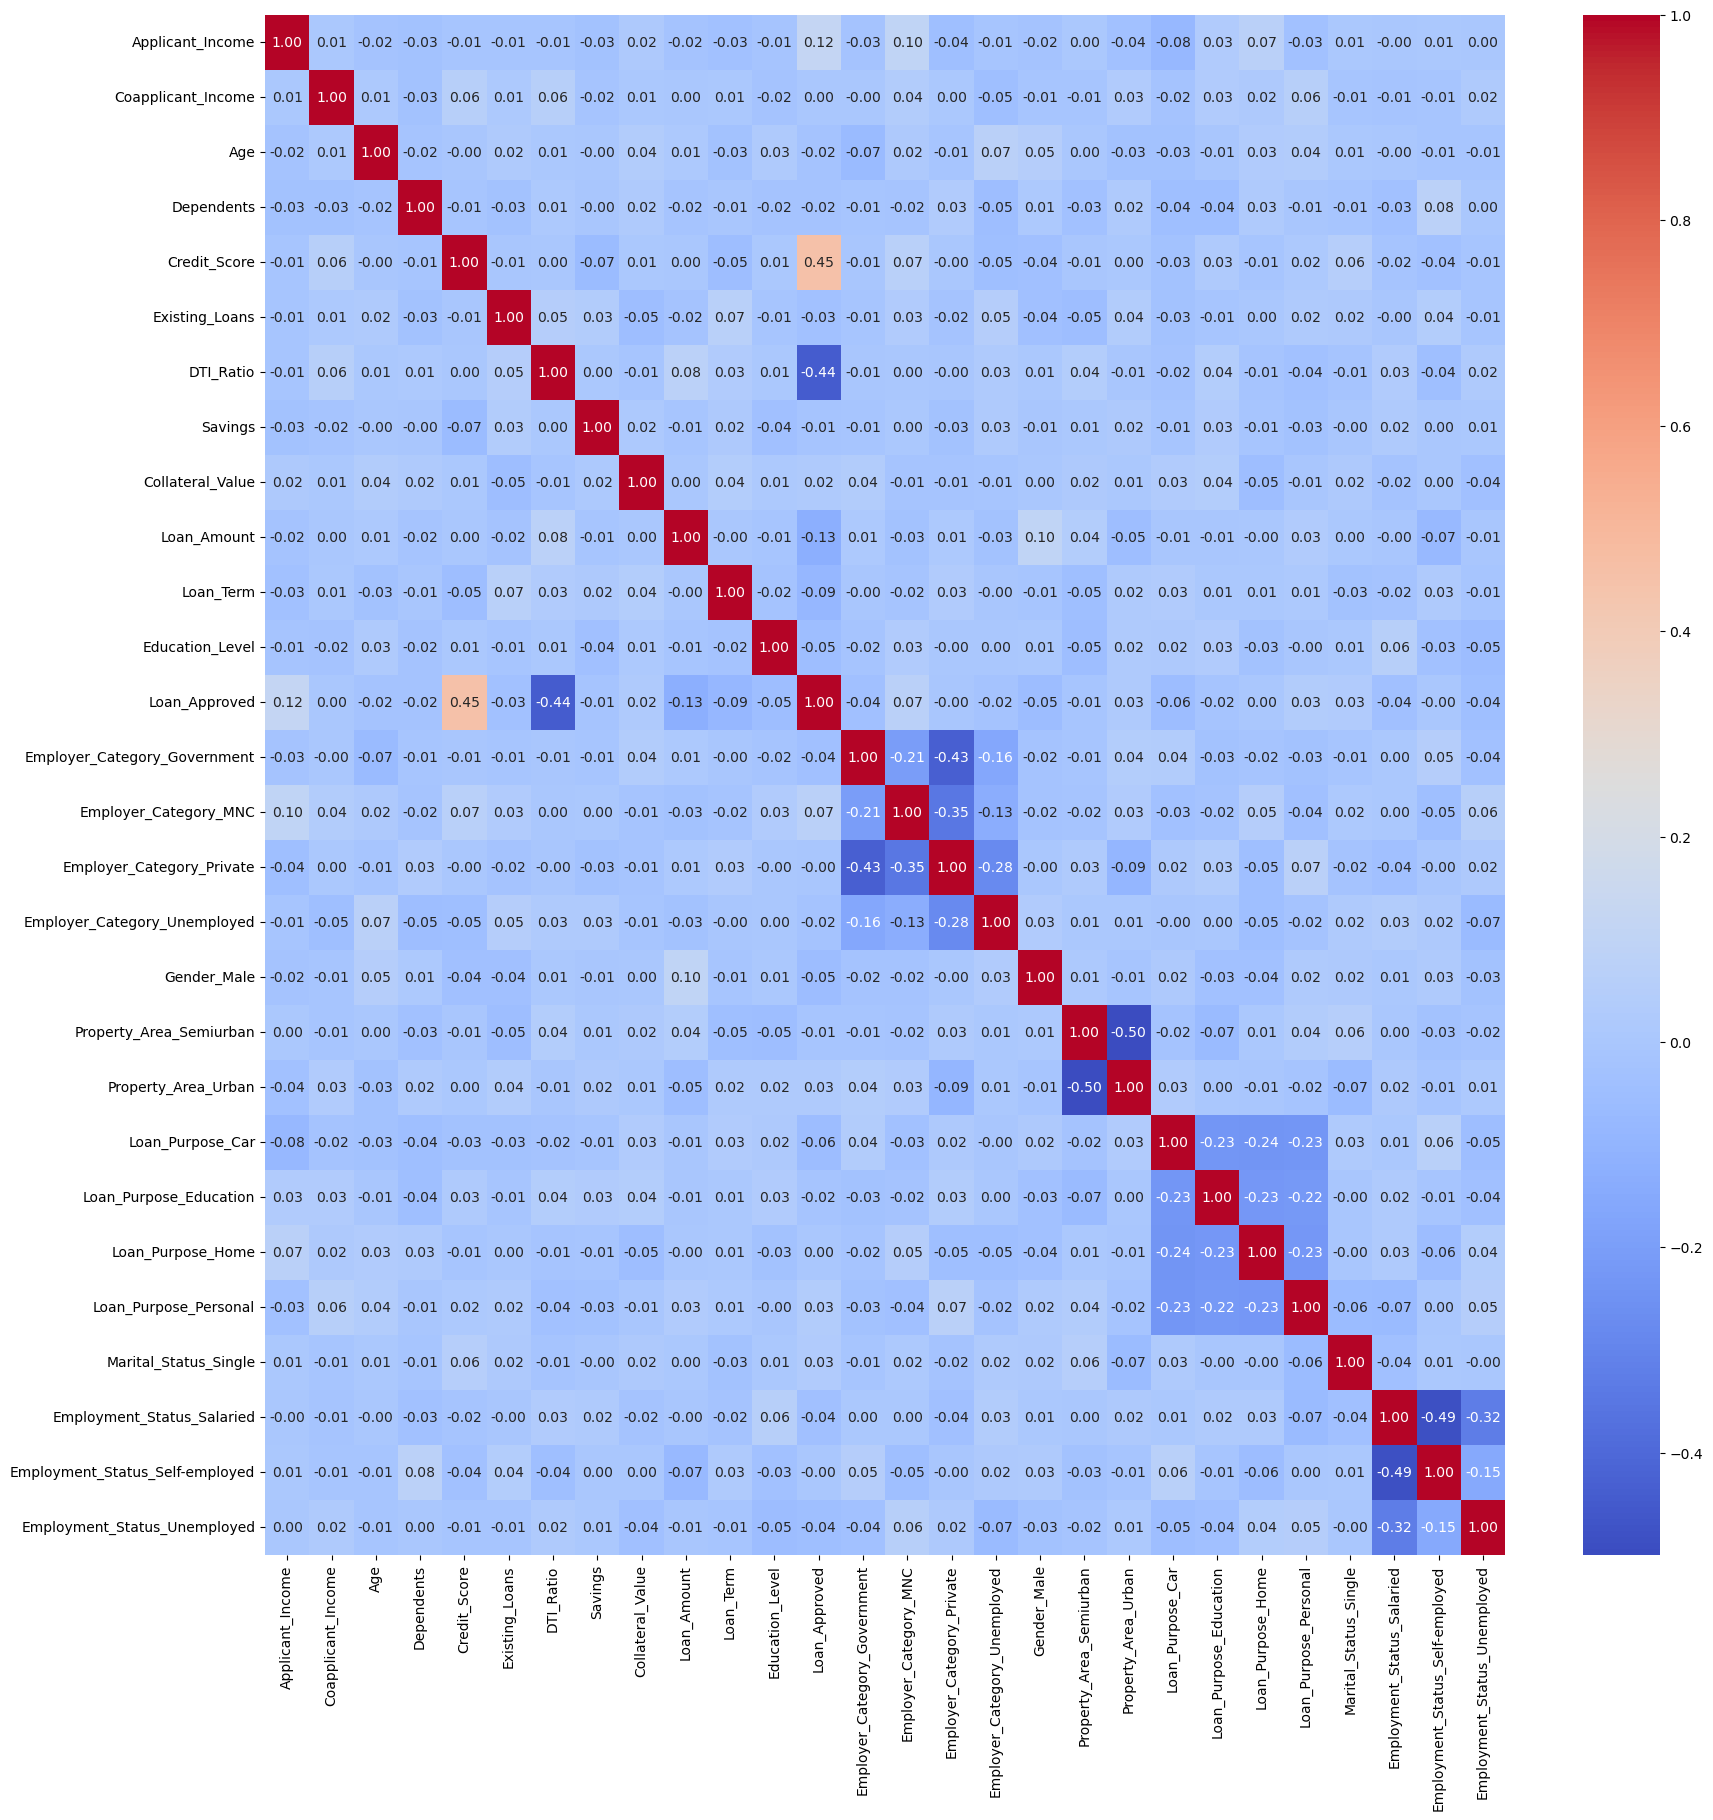

In [36]:
plt.figure(figsize = (20,20))
sns.heatmap(
    coor_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"

)

# Training

In [37]:
X = loan_data.drop(columns = ["Loan_Approved"])
y = loan_data["Loan_Approved"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [44]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Train and Test 

In [47]:
#Logistic Regression
model_1 = LogisticRegression(max_iter = 1000)
model_1.fit(X_train_std,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [48]:
y_predict = model_1.predict(X_test_std)

In [53]:
# Evalution
print("Precision:",precision_score(y_test,y_predict)*100)
print("Recall:",recall_score(y_test,y_predict)*100)
print("confusion_matrix",confusion_matrix(y_test,y_predict))

Precision: 78.33333333333333
Recall: 77.04918032786885
confusion_matrix [[126  13]
 [ 14  47]]


In [56]:
model_2 = GaussianNB()
model_2.fit(X_train_std,y_train)
y_predict = model_2.predict(X_test_std)
print("Precision:",precision_score(y_test,y_predict)*100)
print("Recall:",recall_score(y_test,y_predict)*100)
print("confusion_matrix",confusion_matrix(y_test,y_predict))


Precision: 80.35714285714286
Recall: 73.77049180327869
confusion_matrix [[128  11]
 [ 16  45]]


In [57]:
loan_data["DTI_Ratio_sq"] = loan_data["DTI_Ratio"] **2
loan_data["Credit_Score_sq"] = loan_data["Credit_Score"] **2
loan_data = loan_data.drop(columns = ["DTI_Ratio","Credit_Score"])


In [58]:
X = loan_data.drop(columns = ["Loan_Approved"])
y = loan_data["Loan_Approved"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [59]:
model_1 = LogisticRegression(max_iter = 1000)
model_1.fit(X_train_std,y_train)
y_predict = model_1.predict(X_test_std)
print("Precision:",precision_score(y_test,y_predict)*100)
print("Recall:",recall_score(y_test,y_predict)*100)
print("confusion_matrix",confusion_matrix(y_test,y_predict))

Precision: 79.03225806451613
Recall: 80.32786885245902
confusion_matrix [[126  13]
 [ 12  49]]


In [60]:
model_2 = GaussianNB()
model_2.fit(X_train_std,y_train)
y_predict = model_2.predict(X_test_std)
print("Precision:",precision_score(y_test,y_predict)*100)
print("Recall:",recall_score(y_test,y_predict)*100)
print("confusion_matrix",confusion_matrix(y_test,y_predict))

Precision: 78.33333333333333
Recall: 77.04918032786885
confusion_matrix [[126  13]
 [ 14  47]]
